In [1]:
import pandas as pd
from sqlalchemy import create_engine

DB_USER = "sandeepundurthi"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "ecommerce_delay_db"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

query = "SELECT * FROM shipment_data LIMIT 5"

df = pd.read_sql(query, engine)

df

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_the_product,prior_purchases,product_importance,gender,discount_offered,weight_in_gms,reached_on_time,is_delayed
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,0
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,0
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,0
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,0
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,0


In [2]:
query = "SELECT * FROM shipment_data"

df = pd.read_sql(query, engine)

df.shape

(10999, 13)

In [3]:
df.head()

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_the_product,prior_purchases,product_importance,gender,discount_offered,weight_in_gms,reached_on_time,is_delayed
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,0
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,0
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,0
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,0
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,0


In [4]:
delay_rate = df["is_delayed"].mean() * 100
on_time_rate = 100 - delay_rate

print(f"Delay Rate: {delay_rate:.2f}%")
print(f"On-Time Rate: {on_time_rate:.2f}%")

Delay Rate: 40.33%
On-Time Rate: 59.67%


In [5]:
warehouse_perf = (
    df.groupby('warehouse_block')['is_delayed']
    .mean()
    .sort_values(ascending=False) * 100
)

warehouse_perf

warehouse_block
A    41.352973
C    40.316421
D    40.239913
F    40.152755
B    39.770867
Name: is_delayed, dtype: float64

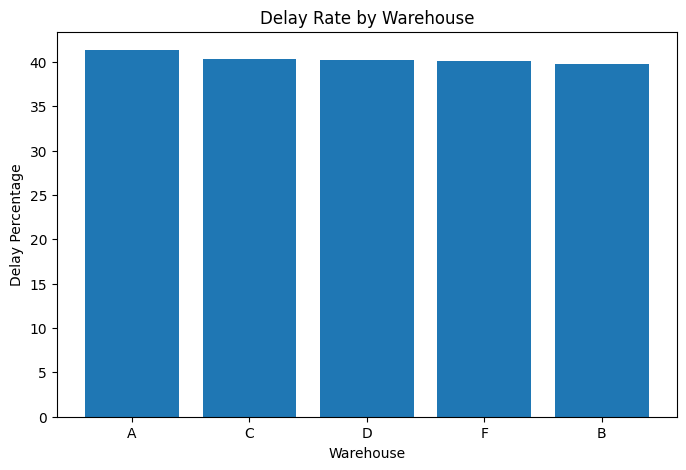

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    warehouse_perf.index,
    warehouse_perf.values
)

plt.title("Delay Rate by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Delay Percentage")

plt.show()

In [7]:
shipment_perf = (
    df.groupby('mode_of_shipment')['is_delayed']
    .mean() * 100
)

shipment_perf

mode_of_shipment
Flight    39.842431
Road      41.193182
Ship      40.243902
Name: is_delayed, dtype: float64

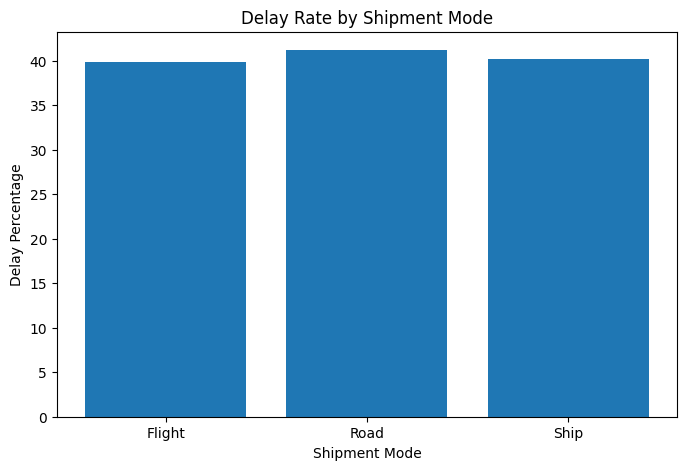

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    shipment_perf.index,
    shipment_perf.values
)

plt.title("Delay Rate by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Delay Percentage")

plt.show()

In [9]:
importance_perf = (
    df.groupby('product_importance')['is_delayed']
    .mean() * 100
)

importance_perf

product_importance
high      35.021097
low       40.721163
medium    40.954985
Name: is_delayed, dtype: float64

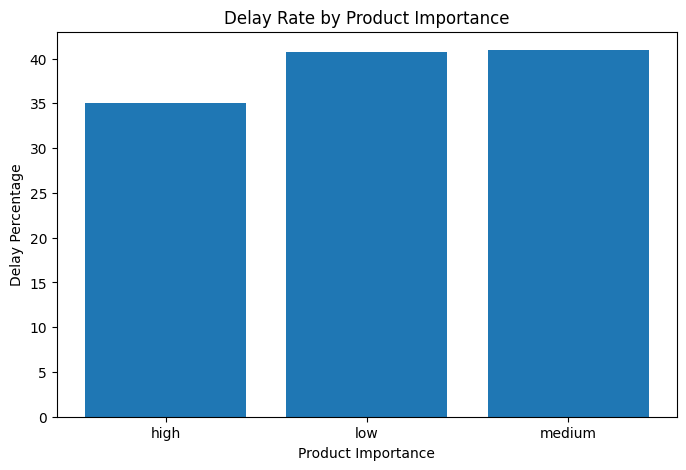

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_perf.index,
    importance_perf.values
)

plt.title("Delay Rate by Product Importance")
plt.xlabel("Product Importance")
plt.ylabel("Delay Percentage")

plt.show()

In [11]:
calls_perf = (
    df.groupby('customer_care_calls')['is_delayed']
    .mean() * 100
)

calls_perf

customer_care_calls
2    34.796238
3    37.488343
4    40.230531
5    41.580756
6    48.371175
7    48.373984
Name: is_delayed, dtype: float64

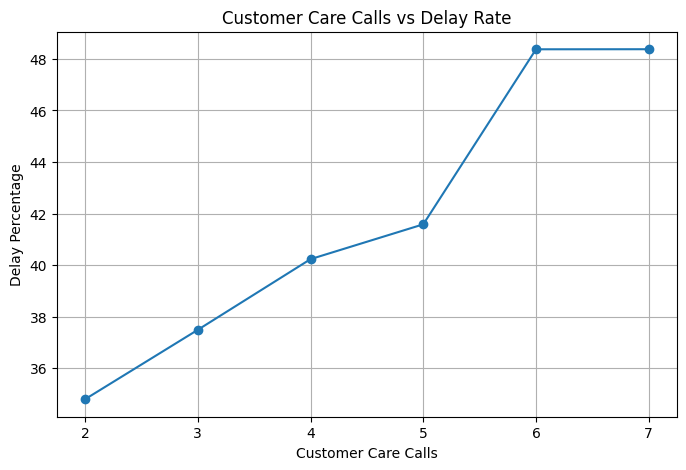

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    calls_perf.index,
    calls_perf.values,
    marker='o'
)

plt.title("Customer Care Calls vs Delay Rate")
plt.xlabel("Customer Care Calls")
plt.ylabel("Delay Percentage")

plt.grid(True)

plt.show()

In [13]:
numeric_cols = df.select_dtypes(include='number')

numeric_cols.head()

,id,customer_care_calls,customer_rating,cost_of_the_product,prior_purchases,discount_offered,weight_in_gms,reached_on_time,is_delayed
0,1,4,2,177,3,44,1233,1,0
1,2,4,5,216,2,59,3088,1,0
2,3,2,2,183,4,48,3374,1,0
3,4,3,3,176,4,10,1177,1,0
4,5,2,2,184,3,46,2484,1,0


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

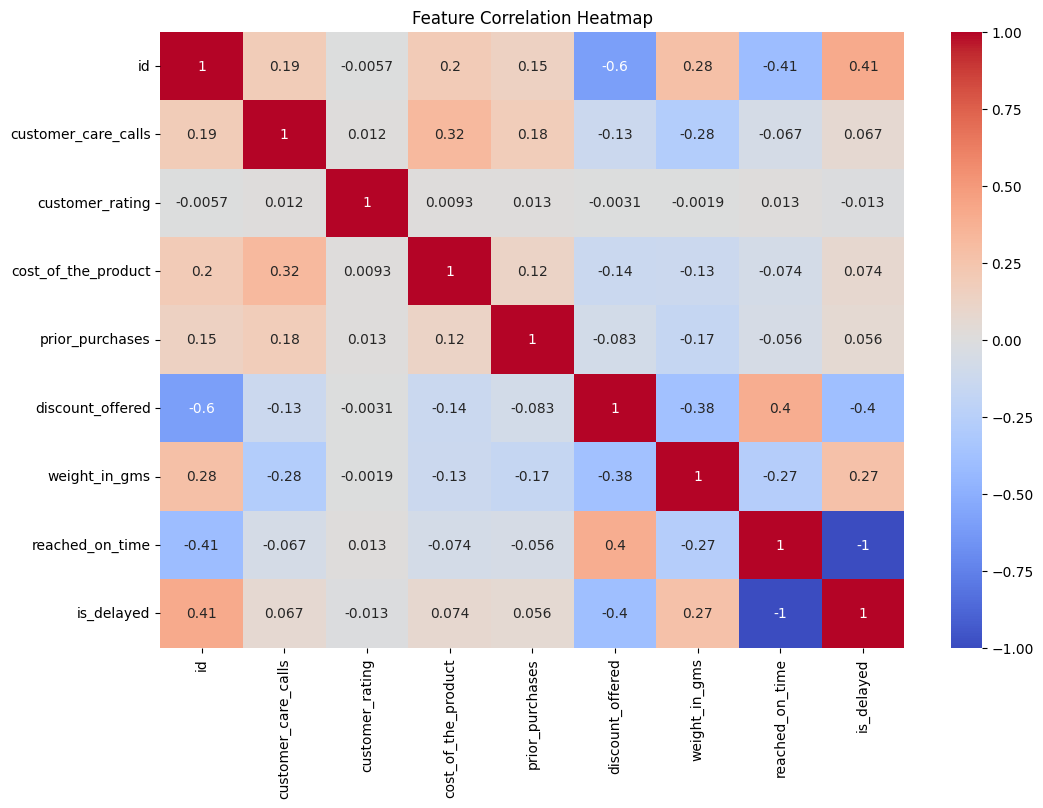

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()